## 02 — Data Quality Audit

This notebook audits the raw Statcast + Fangraph enriched frame before any analysis or modelling. The goal is to understand the data's shape, completeness, and column types so that decisions in notebooks 03 (pitch distribution EDA) and 04 (feature importance) are grounded in reality rather than assumptions.

**Sections:**
1. Row-Level Sanity Checks
2. Missingness Analysis
3. Feature Type Classification

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import pybaseball
from pybaseball import (
    cache,
    statcast,
    statcast_pitcher_pitch_arsenal,
    statcast_pitcher_arsenal_stats,
    statcast_batter_expected_stats,
    statcast_batter_pitch_arsenal,
)
from matplotlib.patches import Patch

sys.path.append(str(Path("..").resolve()))
from utils.features.feature_names import (
    TRAINABLE_COLUMNS,
    LABEL_COLUMN,
    STATCAST_PRE_PITCH,
    FANGRAPH_PRE_PITCH,
)

DATA_DIR = Path("..") / "data" / "cache"
DATA_DIR.mkdir(parents=True, exist_ok=True)
cache.config.cache_directory = str(DATA_DIR.resolve())
cache.config.save()
cache.enable()

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

### Canonical pitch type codes (mirrors _PITCH_TYPES in feature_names.py)
PITCH_TYPES = ["FF", "SI", "FC", "SL", "CH", "CU", "FS", "KN", "ST", "SV"]

print("pybaseball :", pybaseball.__version__)
print("pandas     :", pd.__version__)
print("cache dir  :", cache.config.cache_directory)

pybaseball : 2.2.7
pandas     : 2.2.3
cache dir  : C:\Users\ihuang\Documents\python projects\MLB-Pitch-Predictor\data\cache


In [2]:
SEASON = 2024
PRIOR  = SEASON - 1

df = statcast("2024-06-01", "2024-06-30")
print(f"Raw Statcast shape: {df.shape}")

This is a large query, it may take a moment to complete


100%|██████████| 30/30 [00:00<00:00, 82.81it/s]


Raw Statcast shape: (116355, 118)


In [ ]:
### Pitcher pitch-usage % (prior year)
pit_usage = statcast_pitcher_pitch_arsenal(PRIOR, arsenal_type="n_")
pit_usage_w = pit_usage.rename(columns={"pitcher_id": "pitcher"})  # col is already 'pitcher', no-op

### Pitcher per-pitch outcome stats (prior year)
pit_outcomes = statcast_pitcher_arsenal_stats(PRIOR, minPA=25)
pit_out_stat_cols = [
    c for c in pit_outcomes.columns
    if c not in ["last_name, first_name", "player_id", "team_name_alt", "pitch_type", "pitch_name"]
]
pit_outcomes_w = pit_outcomes.pivot_table(
    index="player_id", columns="pitch_type", values=pit_out_stat_cols, aggfunc="first"
)
pit_outcomes_w.columns = [f"{stat}_{pt}" for stat, pt in pit_outcomes_w.columns]
pit_outcomes_w = pit_outcomes_w.reset_index().rename(columns={"player_id": "pitcher"})

### Batter expected stats (prior year)
bat_xstats = statcast_batter_expected_stats(PRIOR)
bat_xstats_w = bat_xstats.rename(columns={"player_id": "batter"}).drop(
    columns=["last_name, first_name", "year"], errors="ignore"
)

### Batter vs pitch-type stats pivoted wide (prior year)
bat_vs_pitch = statcast_batter_pitch_arsenal(PRIOR, minPA=25)
bat_vs_stat_cols = [
    c for c in bat_vs_pitch.columns
    if c not in ["last_name, first_name", "player_id", "team_name_alt", "pitch_type", "pitch_name"]
]
bat_vs_pitch_w = bat_vs_pitch.pivot_table(
    index="player_id", columns="pitch_type", values=bat_vs_stat_cols, aggfunc="first"
)
bat_vs_pitch_w.columns = [f"bat_{stat}_{pt}" for stat, pt in bat_vs_pitch_w.columns]
bat_vs_pitch_w = bat_vs_pitch_w.reset_index().rename(columns={"player_id": "batter"})

### Merge all enrichment onto the pitch-level frame
df_enr = (
    df
    .merge(pit_usage_w,    on="pitcher", how="left", suffixes=("", "_pu"))
    .merge(pit_outcomes_w, on="pitcher", how="left", suffixes=("", "_po"))
    .merge(bat_xstats_w,   on="batter",  how="left", suffixes=("", "_bx"))
    .merge(bat_vs_pitch_w, on="batter",  how="left", suffixes=("", "_bv"))
)

print(f"Raw shape     : {df.shape}")
print(f"Enriched shape: {df_enr.shape}")
if "n_ff" in df_enr.columns:
    print(f"Pitcher arsenal coverage (n_ff non-null): {df_enr['n_ff'].notna().mean():.1%}")

Raw shape     : (116355, 118)
Enriched shape: (116355, 410)
Pitcher arsenal coverage (n_ff non-null): 75.0%


In [4]:
available    = [c for c in TRAINABLE_COLUMNS if c in df_enr.columns]
missing_cols = [c for c in TRAINABLE_COLUMNS if c not in df_enr.columns]

model_df = df_enr[available + [LABEL_COLUMN]].copy()
model_df = model_df[model_df[LABEL_COLUMN].isin(PITCH_TYPES)].reset_index(drop=True)

print(f"model_df shape          : {model_df.shape}")
print(f"TRAINABLE_COLUMNS total : {len(TRAINABLE_COLUMNS)}")
print(f"Found in enriched frame : {len(available)}")
if missing_cols:
    preview = missing_cols[:5]
    ellipsis = "..." if len(missing_cols) > 5 else ""
    print(f"Missing ({len(missing_cols)})            : {preview}{ellipsis}")
print(f"\nPitch type distribution:\n{model_df[LABEL_COLUMN].value_counts()}")

model_df shape          : (114080, 323)
TRAINABLE_COLUMNS total : 352
Found in enriched frame : 322
Missing (30)            : ['bat_run_value_per_100_KN', 'bat_run_value_per_100_SV', 'bat_run_value_KN', 'bat_run_value_SV', 'bat_pitches_KN']...

Pitch type distribution:
pitch_type
FF    37126
SI    18600
SL    16954
CH    11444
FC     9449
ST     8264
CU     7663
FS     3747
SV      563
KN      270
Name: count, dtype: int64


---
## Section 1 — Row-Level Sanity Checks

Confirm the raw pull covers the expected date window, contains no accidental duplicates, and that filtering to known `PITCH_TYPES` doesn't silently discard a significant fraction of pitches.

In [5]:
### Date range, total rows, and pitch label coverage
print('Date range:', df['game_date'].min(), '→', df['game_date'].max())
print('Raw rows  :', len(df))
print('Enriched  :', len(df_enr))
print('model_df  :', len(model_df), '(after filtering to known PITCH_TYPES)\n')

### All pitch_type values in the raw pull, before filtering
raw_counts = df['pitch_type'].value_counts(dropna=False)
in_types   = raw_counts[raw_counts.index.isin(PITCH_TYPES)]
out_types  = raw_counts[~raw_counts.index.isin(PITCH_TYPES)]
print(f'Pitch types kept ({in_types.sum():,} rows):')
print(in_types.to_string())
print(f'\nPitch types dropped ({out_types.sum():,} rows):')
print(out_types.to_string())

Date range: 2024-06-01 00:00:00 → 2024-06-30 00:00:00
Raw rows  : 116355
Enriched  : 116355
model_df  : 114080 (after filtering to known PITCH_TYPES)

Pitch types kept (114,080 rows):
pitch_type
FF    37126
SI    18600
SL    16954
CH    11444
FC     9449
ST     8264
CU     7663
FS     3747
SV      563
KN      270

Pitch types dropped (2,275 rows):
pitch_type
KC      1627
None     416
FA        93
EP        89
FO        30
CS        13
PO         7


In [6]:
### Duplicate row detection
KEY_COLS = ['game_pk', 'at_bat_number', 'pitch_number']

full_dups = df_enr.duplicated().sum()
key_dups  = df_enr.duplicated(subset=KEY_COLS).sum()

print(f'Full-row duplicates : {full_dups}')
print(f'Key-column duplicates ({KEY_COLS}): {key_dups}')
if key_dups > 0:
    print('\nSample duplicate keys:')
    dup_mask = df_enr.duplicated(subset=KEY_COLS, keep=False)
    print(df_enr[dup_mask][KEY_COLS + ['pitch_type']].head(10))

Full-row duplicates : 0
Key-column duplicates (['game_pk', 'at_bat_number', 'pitch_number']): 0


Total game dates : 30
Median pitches/date: 4226
Sparse dates (< 200 pitches): 0


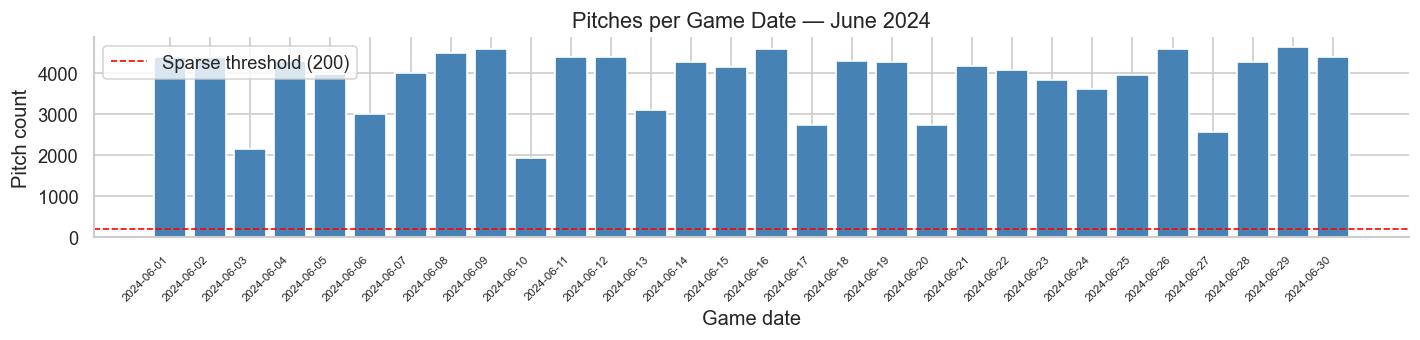

In [ ]:
### Pitches per game-date — flag sparse dates
SPARSE_THRESHOLD = 200  ### fewer than this pitches on a date is worth noting

per_date = df_enr.groupby('game_date').size().sort_index()
sparse   = per_date[per_date < SPARSE_THRESHOLD]

print(f'Total game dates : {len(per_date)}')
print(f'Median pitches/date: {per_date.median():.0f}')
print(f'Sparse dates (< {SPARSE_THRESHOLD} pitches): {len(sparse)}')
if len(sparse):
    print(sparse.to_string())

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(per_date.index.astype(str), per_date.values, width=0.8, color='steelblue')
ax.axhline(SPARSE_THRESHOLD, color='red', linestyle='--', linewidth=1, label=f'Sparse threshold ({SPARSE_THRESHOLD})')
ax.set_xlabel('Game date')
ax.set_ylabel('Pitch count')
ax.set_title('Pitches per Game Date — June 2024', fontsize=13)
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=7)
sns.despine()
plt.tight_layout()
plt.show()